<a href="https://colab.research.google.com/github/LopesMick/analise-exploratoria-fraudes-cartao/blob/main/analise_exploratoria_fraudes_cartao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise Exploratória de Dados para Detecção de Fraudes em Transações de Cartão de Crédito

## Descrição do Projeto

Este projeto tem como objetivo realizar uma **Análise Exploratória de Dados (EDA — Exploratory Data Analysis)** sobre um conjunto de dados de transações realizadas com cartões de crédito, buscando compreender as principais características das operações legítimas e fraudulentas.

O dataset contém informações de transações classificadas em duas categorias: **transações legítimas** e **transações fraudulentas**. Por questões de confidencialidade e proteção dos dados, grande parte das variáveis originais foi anonimizada e representada pelas variáveis `V1` a `V28`.

Além dessas variáveis, o conjunto de dados contém:

- `Time`: tempo decorrido entre as transações;
- `Amount`: valor da transação;
- `Class`: classificação da transação, sendo `0` para legítima e `1` para fraude.

## Objetivo

O objetivo principal desta análise é **explorar, tratar e interpretar os dados de transações de cartão de crédito para identificar padrões, diferenças e relações associados à ocorrência de fraudes**.

Ao longo do trabalho serão realizadas etapas de:

- compreensão da estrutura do dataset;
- avaliação da qualidade dos dados;
- identificação de valores ausentes, duplicidades, zeros e possíveis valores atípicos;
- análise da distribuição das transações legítimas e fraudulentas;
- comparação do comportamento das variáveis entre as duas classes;
- investigação do valor das transações e de sua relação com a ocorrência de fraude;
- exploração de relações e correlações entre as variáveis;
- construção de tabelas, indicadores e visualizações;
- síntese dos principais padrões identificados e das limitações da análise.

> **Observação:** o foco deste trabalho é a Análise Exploratória de Dados. Nesta etapa, o objetivo não é construir um modelo preditivo de Machine Learning, mas compreender o comportamento dos dados e identificar evidências relevantes para a detecção de fraudes.


# 1. Importação e Carregamento dos Dados

Nesta etapa são importadas as principais bibliotecas utilizadas durante a Análise Exploratória de Dados (EDA) e realizado o carregamento do dataset `creditcard.csv`.

O conjunto de dados será armazenado em um **DataFrame do Pandas**, estrutura que permite organizar, consultar, transformar e analisar os dados de forma tabular.

Após o carregamento, será realizada uma primeira inspeção para confirmar se o arquivo foi importado corretamente e verificar sua dimensão inicial.

In [ ]:
# ============================================================
# 1. IMPORTAÇÃO DAS BIBLIOTECAS
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Configuração para melhor visualização das tabelas
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


In [ ]:
# ============================================================
# 2. CARREGAMENTO DO DATASET
# ============================================================

arquivo = '/content/creditcard.csv'

df = pd.read_csv(arquivo)

print("Dataset carregado com sucesso!")
print(f"Quantidade de linhas: {df.shape[0]:,}")
print(f"Quantidade de colunas: {df.shape[1]}")

Dataset carregado com sucesso!
Quantidade de linhas: 284,807
Quantidade de colunas: 31


## 1.1 Primeira Visualização do Dataset

Antes de realizar qualquer tratamento ou análise estatística, é importante observar algumas linhas do conjunto de dados.

Essa inspeção inicial permite verificar:

- como os dados estão estruturados;
- quais variáveis estão disponíveis;
- como os valores aparecem no dataset;
- qual é a variável responsável pela identificação das fraudes;
- se existem problemas visíveis logo na primeira inspeção.

In [ ]:
# Visualizando as 5 primeiras linhas do dataset

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.00,-1.36,-0.07,2.54,1.38,-0.34,0.46,0.24,0.10,0.36,0.09,-0.55,-0.62,-0.99,-0.31,1.47,-0.47,0.21,0.03,0.40,0.25,-0.02,0.28,-0.11,0.07,0.13,-0.19,0.13,-0.02,149.62,0
1,0.00,1.19,0.27,0.17,0.45,0.06,-0.08,-0.08,0.09,-0.26,-0.17,1.61,1.07,0.49,-0.14,0.64,0.46,-0.11,-0.18,-0.15,-0.07,-0.23,-0.64,0.10,-0.34,0.17,0.13,-0.01,0.01,2.69,0
2,1.00,-1.36,-1.34,1.77,0.38,-0.50,1.80,0.79,0.25,-1.51,0.21,0.62,0.07,0.72,-0.17,2.35,-2.89,1.11,-0.12,-2.26,0.52,0.25,0.77,0.91,-0.69,-0.33,-0.14,-0.06,-0.06,378.66,0
3,1.00,-0.97,-0.19,1.79,-0.86,-0.01,1.25,0.24,0.38,-1.39,-0.05,-0.23,0.18,0.51,-0.29,-0.63,-1.06,-0.68,1.97,-1.23,-0.21,-0.11,0.01,-0.19,-1.18,0.65,-0.22,0.06,0.06,123.50,0
4,2.00,-1.16,0.88,1.55,0.40,-0.41,0.10,0.59,-0.27,0.82,0.75,-0.82,0.54,1.35,-1.12,0.18,-0.45,-0.24,-0.04,0.80,0.41,-0.01,0.80,-0.14,0.14,-0.21,0.50,0.22,0.22,69.99,0


Class = 0 → Transação legítima -
Class = 1 → Transação fraudulenta

In [ ]:
# Verificando as dimensões do dataset

linhas, colunas = df.shape

print(f"O dataset possui {linhas:,} registros.")
print(f"O dataset possui {colunas} variáveis.")

O dataset possui 284,807 registros.
O dataset possui 31 variáveis.


In [ ]:
# Listando as variáveis disponíveis no dataset

print("Colunas presentes no dataset:\n")

for i, coluna in enumerate(df.columns, start=1):
    print(f"{i:02d} - {coluna}")

Colunas presentes no dataset:

01 - Time
02 - V1
03 - V2
04 - V3
05 - V4
06 - V5
07 - V6
08 - V7
09 - V8
10 - V9
11 - V10
12 - V11
13 - V12
14 - V13
15 - V14
16 - V15
17 - V16
18 - V17
19 - V18
20 - V19
21 - V20
22 - V21
23 - V22
24 - V23
25 - V24
26 - V25
27 - V26
28 - V27
29 - V28
30 - Amount
31 - Class


# 2. Conhecendo o Dataset e seu Domínio

## 2.1 Contexto

O dataset utilizado neste trabalho é o **Credit Card Fraud Detection**, disponibilizado publicamente pelo **Machine Learning Group da Université Libre de Bruxelles (ULB)**.

O conjunto de dados contém transações realizadas por cartões de crédito de clientes europeus durante um período de **dois dias, em setembro de 2013**.

Seu principal objetivo é apoiar estudos relacionados à **detecção de fraudes em transações financeiras**, permitindo analisar diferenças entre operações legítimas e fraudulentas.

Esse tipo de análise é relevante porque fraudes representam uma parcela muito pequena das transações, mas podem gerar impactos financeiros significativos para clientes e instituições financeiras.

## 2.2 Dimensão do Dataset

O dataset possui:

- **284.807 transações**
- **31 variáveis**
- **284.315 transações legítimas**
- **492 transações fraudulentas**
- aproximadamente **0,172% das transações são fraudes**

Essa distribuição evidencia um forte **desbalanceamento entre as classes**, característica comum em problemas de detecção de fraude.

## 2.3 Estrutura das Variáveis

O dataset possui apenas variáveis numéricas.

Por questões de confidencialidade e proteção das informações dos clientes, as características originais das transações não foram disponibilizadas diretamente.

As variáveis `V1` até `V28` foram transformadas através da técnica de **PCA — Principal Component Analysis (Análise de Componentes Principais)**.

As três variáveis que possuem interpretação direta são:

- `Time`: quantidade de segundos decorridos entre cada transação e a primeira transação registrada no dataset;
- `Amount`: valor financeiro da transação;
- `Class`: variável de classificação da transação.

A variável `Class` possui dois valores:

- **0** → transação legítima;
- **1** → transação fraudulenta.

## 2.4 Anonimização e PCA

A utilização de PCA permite transformar as variáveis originais em novos componentes numéricos, preservando parte importante da estrutura estatística dos dados, mas dificultando a identificação das informações originais.

Por esse motivo, não é possível afirmar diretamente o significado de variáveis como `V1`, `V2`, `V3`, ..., `V28`.

Durante esta análise, essas variáveis serão tratadas como componentes numéricos anonimizados e serão avaliadas principalmente através de:

- distribuição;
- medidas estatísticas;
- comparação entre transações legítimas e fraudulentas;
- correlação com a variável `Class`.

## 2.5 Fonte e Licença

**Fonte:** Credit Card Fraud Detection — Machine Learning Group, Université Libre de Bruxelles (ULB), disponibilizado no Kaggle.

**Link:** https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

**Licença:** Open Database License (ODbL).

O dataset é utilizado amplamente em estudos acadêmicos e aplicações educacionais relacionadas a análise de dados, detecção de anomalias e fraude financeira.

In [ ]:
# ============================================================
# VERIFICAÇÃO DA DISTRIBUIÇÃO DAS CLASSES
# ============================================================

quantidade_classes = df['Class'].value_counts().sort_index()

legitimas = quantidade_classes.get(0, 0)
fraudes = quantidade_classes.get(1, 0)
total = len(df)

percentual_legitimas = legitimas / total * 100
percentual_fraudes = fraudes / total * 100

print(f"Total de transações: {total:,}")
print(f"Transações legítimas: {legitimas:,} ({percentual_legitimas:.3f}%)")
print(f"Transações fraudulentas: {fraudes:,} ({percentual_fraudes:.3f}%)")

Total de transações: 284,807
Transações legítimas: 284,315 (99.827%)
Transações fraudulentas: 492 (0.173%)


# 3. Perguntas que irão nortear a Análise Exploratória

A Análise Exploratória de Dados será conduzida a partir das seguintes perguntas de pesquisa:

### Pergunta 1
**Qual é a distribuição entre transações legítimas e fraudulentas no dataset?**

Objetivo: compreender a proporção de cada classe e avaliar o nível de desbalanceamento dos dados.

---

### Pergunta 2
**Qual é a distribuição dos valores das transações (`Amount`) e existem valores extremos ou atípicos?**

Objetivo: compreender o comportamento financeiro das operações e identificar possíveis outliers.

---

### Pergunta 3
**O valor das transações fraudulentas apresenta comportamento diferente do valor das transações legítimas?**

Objetivo: comparar média, mediana, distribuição e dispersão de `Amount` entre as duas classes.

---

### Pergunta 4
**As fraudes apresentam algum padrão em relação ao tempo de ocorrência das transações?**

Objetivo: investigar se a ocorrência de fraude varia ao longo do período representado pela variável `Time`.

---

### Pergunta 5
**Quais variáveis entre `V1` e `V28` apresentam maiores diferenças entre transações legítimas e fraudulentas?**

Objetivo: identificar componentes que apresentam comportamentos estatísticos distintos entre as classes.

---

### Pergunta 6
**Quais variáveis apresentam maior associação ou correlação com a ocorrência de fraude (`Class`)?**

Objetivo: explorar relações estatísticas entre as variáveis numéricas e a classificação das transações.

---

### Pergunta 7
**Existem relações relevantes entre o valor da transação (`Amount`) e outras variáveis do dataset?**

Objetivo: avaliar se o valor financeiro das transações possui associação com outros componentes numéricos.

---

### Pergunta 8
**Quais padrões gerais diferenciam uma transação fraudulenta de uma transação legítima dentro deste dataset?**

Objetivo: consolidar os principais achados da análise exploratória, combinando as evidências obtidas nas perguntas anteriores.

# 4. Exploração Inicial e Avaliação da Qualidade dos Dados

Após compreender o contexto do dataset e definir as perguntas que irão orientar a análise, será realizada uma avaliação inicial da estrutura e da qualidade dos dados.

Nesta etapa serão analisados:

- tipos das variáveis;
- estatísticas descritivas;
- valores ausentes;
- valores duplicados;
- ocorrência de zeros;
- distribuição das classes;
- possíveis valores extremos ou inconsistentes.

O objetivo é identificar problemas que possam comprometer ou influenciar as análises realizadas nas etapas seguintes.

In [ ]:
# ============================================================
# 4.1 INFORMAÇÕES GERAIS DO DATAFRAME
# ============================================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

## 4.2 Estatísticas Descritivas

Nesta etapa são analisadas as principais medidas estatísticas das variáveis numéricas do dataset.

A estatística descritiva permite observar:

- média;
- desvio-padrão;
- valor mínimo;
- quartis;
- mediana;
- valor máximo.

Essa análise ajuda a identificar diferenças de escala, dispersão e possíveis valores extremos que podem influenciar as análises posteriores.

In [ ]:
# ============================================================
# 4.2 ESTATÍSTICAS DESCRITIVAS
# ============================================================

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,"284,807.00","94,813.86","47,488.15",0.00,"54,201.50","84,692.00","139,320.50","172,792.00"
V1,"284,807.00",0.00,1.96,-56.41,-0.92,0.02,1.32,2.45
V2,"284,807.00",0.00,1.65,-72.72,-0.60,0.07,0.80,22.06
V3,"284,807.00",-0.00,1.52,-48.33,-0.89,0.18,1.03,9.38
V4,"284,807.00",0.00,1.42,-5.68,-0.85,-0.02,0.74,16.88
V5,"284,807.00",0.00,1.38,-113.74,-0.69,-0.05,0.61,34.80
V6,"284,807.00",0.00,1.33,-26.16,-0.77,-0.27,0.40,73.30
V7,"284,807.00",-0.00,1.24,-43.56,-0.55,0.04,0.57,120.59
V8,"284,807.00",0.00,1.19,-73.22,-0.21,0.02,0.33,20.01
V9,"284,807.00",-0.00,1.10,-13.43,-0.64,-0.05,0.60,15.59


## 4.3 Verificação de Valores Ausentes

Valores ausentes podem comprometer cálculos estatísticos e análises comparativas.

Por esse motivo, será verificada a quantidade de valores nulos em cada variável do dataset.

In [ ]:
# ============================================================
# 4.3 VERIFICAÇÃO DE VALORES NULOS
# ============================================================

valores_nulos = df.isnull().sum()

resultado_nulos = pd.DataFrame({
    'Quantidade de Nulos': valores_nulos,
    'Percentual (%)': (valores_nulos / len(df)) * 100
})

resultado_nulos = resultado_nulos[
    resultado_nulos['Quantidade de Nulos'] > 0
]

if resultado_nulos.empty:
    print("Não foram identificados valores nulos no dataset.")
else:
    display(resultado_nulos)

Não foram identificados valores nulos no dataset.


## 4.4 Verificação de Registros Duplicados

Registros duplicados podem distorcer frequências, médias, proporções e outras medidas estatísticas.

Nesta etapa será verificada a existência de linhas completamente duplicadas no conjunto de dados.

In [ ]:
# ============================================================
# 4.4 VERIFICAÇÃO DE DUPLICIDADES
# ============================================================

duplicados = df.duplicated().sum()
percentual_duplicados = (duplicados / len(df)) * 100

print(f"Quantidade de registros duplicados: {duplicados:,}")
print(f"Percentual de registros duplicados: {percentual_duplicados:.4f}%")

Quantidade de registros duplicados: 1,081
Percentual de registros duplicados: 0.3796%


## 4.5 Verificação de Valores Iguais a Zero

A presença do valor zero não representa necessariamente um erro.

Em algumas variáveis, como `Class`, o zero possui significado válido, indicando uma transação legítima. Em outras variáveis, como os componentes anonimizados `V1` a `V28`, valores próximos ou iguais a zero também podem ocorrer naturalmente devido às transformações estatísticas aplicadas.

Mesmo assim, será realizada uma contagem dos valores iguais a zero para compreender melhor a estrutura dos dados.

In [ ]:
# ============================================================
# 4.5 CONTAGEM DE VALORES ZERO
# ============================================================

zeros = (df == 0).sum()

resultado_zeros = pd.DataFrame({
    'Quantidade de Zeros': zeros,
    'Percentual (%)': (zeros / len(df)) * 100
})

resultado_zeros.sort_values(
    by='Quantidade de Zeros',
    ascending=False
)

,Quantidade de Zeros,Percentual (%)
Class,284315,99.83
Amount,1825,0.64
Time,2,0.00
V3,0,0.00
V4,0,0.00
V1,0,0.00
V2,0,0.00
V7,0,0.00
V8,0,0.00
V9,0,0.00


## 4.6 Tipos das Variáveis

Também é necessário verificar os tipos de dados das colunas para identificar possíveis inconsistências, como variáveis numéricas armazenadas como texto.

Tipos incorretos podem comprometer cálculos, filtros e visualizações.

In [ ]:
# ============================================================
# 4.6 TIPOS DAS VARIÁVEIS
# ============================================================

tipos = pd.DataFrame({
    'Variável': df.columns,
    'Tipo de Dado': df.dtypes.astype(str).values
})

tipos

,Variável,Tipo de Dado
0,Time,float64
1,V1,float64
2,V2,float64
3,V3,float64
4,V4,float64
5,V5,float64
6,V6,float64
7,V7,float64
8,V8,float64
9,V9,float64


## 4.7 Resumo da Qualidade dos Dados

Após a inspeção inicial, os principais aspectos avaliados foram:

- estrutura do dataset;
- tipos das variáveis;
- valores ausentes;
- registros duplicados;
- ocorrência de valores iguais a zero;
- estatísticas descritivas;
- possíveis valores extremos.

Os resultados dessa etapa serão utilizados para definir os tratamentos necessários antes da Análise Exploratória de Dados propriamente dita.

É importante destacar que nem todo valor extremo ou igual a zero representa um erro. Cada situação deve ser interpretada considerando o contexto da variável e o domínio do problema.

# 5. Tratamento e Preparação dos Dados

Após a exploração inicial e a avaliação da qualidade dos dados, são aplicados os tratamentos necessários para preparar o dataset para a Análise Exploratória de Dados.

Nesta etapa, cada decisão de tratamento será justificada com base nas características identificadas anteriormente.

Serão avaliados:

- registros duplicados;
- valores ausentes;
- valores iguais a zero;
- possíveis outliers;
- transformação da variável `Time`;
- necessidade de normalização;
- criação de variáveis derivadas que facilitem a interpretação dos dados.

## 5.1 Tratamento de Registros Duplicados

Registros duplicados podem aumentar artificialmente a frequência de determinados padrões, afetando médias, proporções e comparações entre grupos.

Como foram identificadas duplicidades no dataset, será criada uma nova versão dos dados sem registros duplicados.

Essa remoção busca evitar que uma mesma observação seja contabilizada mais de uma vez durante a análise.

In [ ]:
# ============================================================
# 5.1 REMOÇÃO DE REGISTROS DUPLICADOS
# ============================================================

linhas_antes = len(df)

df_tratado = df.drop_duplicates().copy()

linhas_depois = len(df_tratado)

removidos = linhas_antes - linhas_depois

print(f"Quantidade de registros antes do tratamento: {linhas_antes:,}")
print(f"Quantidade de registros após o tratamento: {linhas_depois:,}")
print(f"Quantidade de registros duplicados removidos: {removidos:,}")

Quantidade de registros antes do tratamento: 284,807
Quantidade de registros após o tratamento: 283,726
Quantidade de registros duplicados removidos: 1,081


## 5.2 Tratamento de Valores Ausentes

A análise inicial não identificou valores ausentes no dataset.

Dessa forma, não foi necessário aplicar técnicas de:

- imputação pela média;
- imputação pela mediana;
- interpolação;
- extrapolação;
- regressão para preenchimento de valores.

Aplicar essas técnicas sem necessidade poderia introduzir valores artificiais e viés nos dados.

Portanto, os dados foram mantidos sem imputação.

## 5.3 Avaliação dos Valores Iguais a Zero

A presença de valores iguais a zero foi analisada individualmente considerando o significado de cada variável.

No caso da variável `Class`, o valor zero possui significado válido e representa uma transação legítima.

Nas variáveis `V1` a `V28`, valores iguais ou próximos de zero podem ocorrer naturalmente devido à transformação estatística realizada por PCA.

Na variável `Amount`, uma transação com valor igual a zero também pode representar um registro válido dentro do dataset.

Por esse motivo, os valores iguais a zero não serão removidos automaticamente.

## 5.4 Identificação de Valores Atípicos em `Amount`

A variável `Amount` representa o valor financeiro das transações.

Como valores financeiros geralmente apresentam distribuição assimétrica, é possível que existam transações com valores muito superiores à maioria dos registros.

Esses valores serão analisados como possíveis outliers.

No entanto, valores extremos não serão removidos automaticamente, pois uma transação de alto valor pode ser legítima e relevante para a análise de fraude.

In [ ]:
# ============================================================
# 5.4 ANÁLISE DE OUTLIERS - AMOUNT
# ============================================================

Q1 = df_tratado['Amount'].quantile(0.25)
Q3 = df_tratado['Amount'].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers_amount = df_tratado[
    (df_tratado['Amount'] < limite_inferior) |
    (df_tratado['Amount'] > limite_superior)
]

print(f"Q1: {Q1:.2f}")
print(f"Q3: {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Limite inferior: {limite_inferior:.2f}")
print(f"Limite superior: {limite_superior:.2f}")
print(f"Quantidade de possíveis outliers em Amount: {len(outliers_amount):,}")

Q1: 5.60
Q3: 77.51
IQR: 71.91
Limite inferior: -102.27
Limite superior: 185.38
Quantidade de possíveis outliers em Amount: 31,685


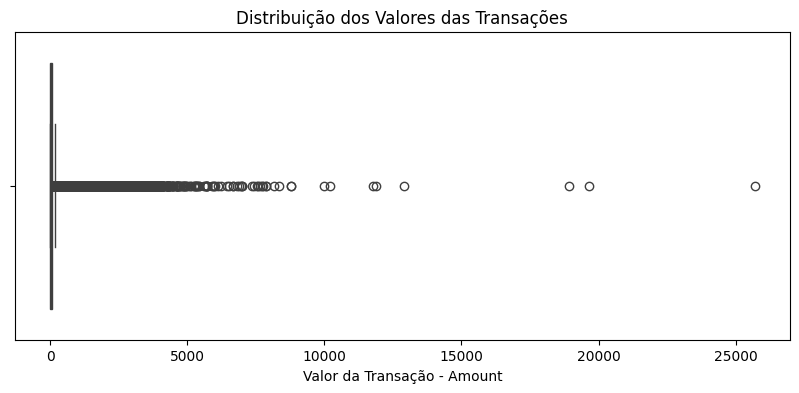

In [ ]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    x=df_tratado['Amount']
)

plt.title('Distribuição dos Valores das Transações')
plt.xlabel('Valor da Transação - Amount')

plt.show()

### Justificativa do gráfico

Foi utilizado um **boxplot** porque esse tipo de gráfico permite visualizar de forma clara:

- mediana;
- quartis;
- dispersão;
- possíveis valores atípicos.

Ele é mais adequado do que um gráfico de barras para identificar outliers em uma variável numérica contínua como `Amount`.


## 5.6 Transformação da Variável `Time`

A variável `Time` representa a quantidade de segundos transcorridos desde a primeira transação registrada no dataset.

Para facilitar a interpretação dos resultados, será criada uma nova variável chamada `Time_Hours`, convertendo os segundos para horas.

Essa transformação não altera a informação original, apenas torna a escala temporal mais intuitiva para análise e visualização.

In [ ]:
# ============================================================
# 5.6 CRIAÇÃO DA VARIÁVEL TIME_HOURS
# ============================================================

df_tratado['Time_Hours'] = df_tratado['Time'] / 3600

df_tratado[['Time', 'Time_Hours']].head()

,Time,Time_Hours
0,0.00,0.00
1,0.00,0.00
2,1.00,0.00
3,1.00,0.00
4,2.00,0.00


In [ ]:
# ============================================================
# 5.7 CRIAÇÃO DE FAIXAS TEMPORAIS
# ============================================================

df_tratado['Time_Period'] = pd.cut(
    df_tratado['Time_Hours'],
    bins=[0, 12, 24, 36, 48],
    labels=[
        '0-12h',
        '12-24h',
        '24-36h',
        '36-48h'
    ],
    include_lowest=True
)

df_tratado[['Time_Hours', 'Time_Period']].head()

,Time_Hours,Time_Period
0,0.00,0-12h
1,0.00,0-12h
2,0.00,0-12h
3,0.00,0-12h
4,0.00,0-12h


## 5.8 Avaliação da Necessidade de Normalização

A normalização é utilizada para colocar variáveis em escalas comparáveis.

Neste trabalho, o objetivo principal é realizar uma Análise Exploratória de Dados, e não construir um modelo preditivo.

As variáveis `V1` a `V28` já foram transformadas por PCA, enquanto `Amount` e `Time` possuem escalas próprias e serão analisadas de forma interpretável.

Por esse motivo, não será aplicada normalização global ao dataset nesta etapa.

Caso alguma comparação específica exija variáveis na mesma escala, essa transformação poderá ser aplicada apenas naquela análise.

## 5.9 Transformação Logarítmica de `Amount`

A variável `Amount` apresenta forte assimetria, com grande concentração de transações de baixo valor e uma cauda formada por transações de valores elevados.

Para facilitar algumas visualizações, foi criada a variável `Amount_Log`, utilizando a transformação:

`log(1 + Amount)`

A transformação logarítmica reduz o impacto visual dos valores extremos sem remover observações do dataset.

A variável original `Amount` foi preservada e continua sendo utilizada sempre que a interpretação em valores monetários é necessária.

# 6. Análise Exploratória de Dados — EDA

## 6.1 Pergunta 1 — Qual é a distribuição entre transações legítimas e fraudulentas?

O objetivo desta análise é identificar a proporção de cada classe presente no dataset e avaliar o nível de desbalanceamento entre transações legítimas e fraudulentas.

Essa análise é importante porque problemas de detecção de fraude costumam apresentar uma quantidade muito pequena de ocorrências fraudulentas em comparação com as transações normais.

In [ ]:
# ============================================================
# 6.1 DISTRIBUIÇÃO DAS CLASSES
# ============================================================

distribuicao_classes = (
    df_tratado['Class']
    .value_counts()
    .sort_index()
)

percentual_classes = (
    df_tratado['Class']
    .value_counts(normalize=True)
    .sort_index() * 100
)

resultado_classes = pd.DataFrame({
    'Quantidade': distribuicao_classes,
    'Percentual (%)': percentual_classes
})

resultado_classes.index = ['Legítima', 'Fraude']

resultado_classes

,Quantidade,Percentual (%)
Legítima,283253,99.83
Fraude,473,0.17


### Justificativa do gráfico

Foi utilizado um **gráfico de barras** porque o objetivo é comparar a quantidade de observações entre duas categorias discretas: transações legítimas e fraudulentas.

O gráfico de barras permite visualizar de forma direta a grande diferença de frequência entre as duas classes.

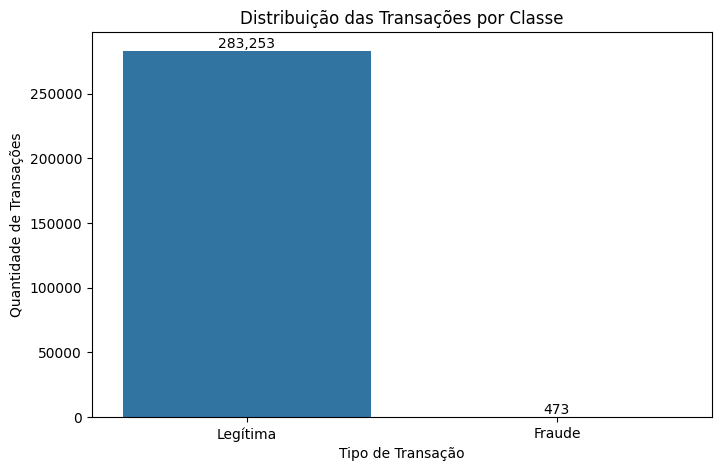

In [ ]:
# ============================================================
# GRÁFICO - DISTRIBUIÇÃO DAS CLASSES
# ============================================================

contagem = df_tratado['Class'].value_counts().sort_index()

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=['Legítima', 'Fraude'],
    y=contagem.values
)

plt.title('Distribuição das Transações por Classe')
plt.xlabel('Tipo de Transação')
plt.ylabel('Quantidade de Transações')

for i, valor in enumerate(contagem.values):
    ax.text(
        i,
        valor,
        f'{valor:,}',
        ha='center',
        va='bottom'
    )

plt.show()

### Conclusão da Pergunta 1

A análise demonstra que o dataset apresenta um forte **desbalanceamento entre as classes**.

A grande maioria das operações corresponde a transações legítimas, enquanto as fraudes representam apenas uma pequena parcela do total.

Esse resultado é consistente com o contexto real de detecção de fraude, no qual eventos fraudulentos tendem a ser relativamente raros.

O desbalanceamento deve ser considerado ao interpretar os resultados da análise, pois medidas baseadas apenas em quantidade absoluta podem mascarar o comportamento da classe minoritária.

## 6.2 Pergunta 2 — Qual é a distribuição dos valores das transações (`Amount`) e existem valores extremos?

O objetivo desta análise é compreender como os valores financeiros das transações estão distribuídos.

Serão analisados:

- média;
- mediana;
- desvio-padrão;
- valor mínimo;
- quartis;
- valor máximo;
- possíveis valores extremos.

Como valores financeiros podem apresentar forte assimetria, serão utilizadas diferentes visualizações para representar adequadamente a distribuição.

In [ ]:
# ============================================================
# 6.2 ESTATÍSTICAS DA VARIÁVEL AMOUNT
# ============================================================

estatisticas_amount = df_tratado['Amount'].describe()

print("Estatísticas da variável Amount:\n")
print(estatisticas_amount)

print("\nMediana:")
print(f"{df_tratado['Amount'].median():.2f}")

Estatísticas da variável Amount:

count   283,726.00
mean         88.47
std         250.40
min           0.00
25%           5.60
50%          22.00
75%          77.51
max      25,691.16
Name: Amount, dtype: float64

Mediana:
22.00


### Justificativa do histograma

Foi utilizado um **histograma** porque `Amount` é uma variável numérica contínua.

Esse tipo de gráfico permite visualizar:

- concentração dos valores;
- formato da distribuição;
- assimetria;
- existência de caudas longas;
- regiões com maior frequência de transações.

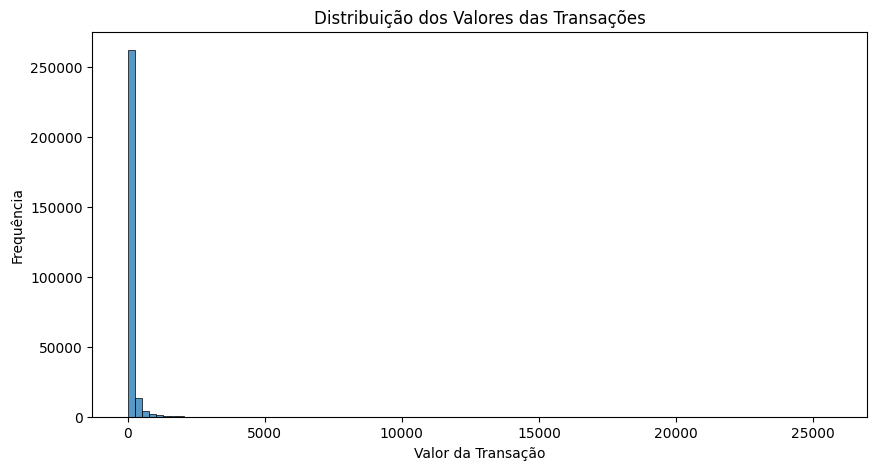

In [ ]:
# ============================================================
# HISTOGRAMA - AMOUNT
# ============================================================

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df_tratado,
    x='Amount',
    bins=100
)

plt.title('Distribuição dos Valores das Transações')
plt.xlabel('Valor da Transação')
plt.ylabel('Frequência')

plt.show()

### Visualização em escala logarítmica

A distribuição original de `Amount` possui uma cauda longa causada por transações de valores elevados.

Por esse motivo, também será analisada a transformação:

`log(1 + Amount)`

Essa transformação reduz o impacto visual dos valores extremos e facilita a observação da concentração da maior parte das transações.

A transformação é utilizada apenas para visualização e interpretação, preservando a variável original no dataset.

### Justificativa do boxplot

O **boxplot** complementa o histograma porque permite visualizar a mediana, os quartis e possíveis valores extremos.

Enquanto o histograma mostra o formato geral da distribuição, o boxplot facilita a identificação de observações muito distantes da região central dos dados.

Coluna Amount_Log criada com sucesso!
   Amount  Amount_Log
0  149.62        5.01
1    2.69        1.31
2  378.66        5.94
3  123.50        4.82
4   69.99        4.26


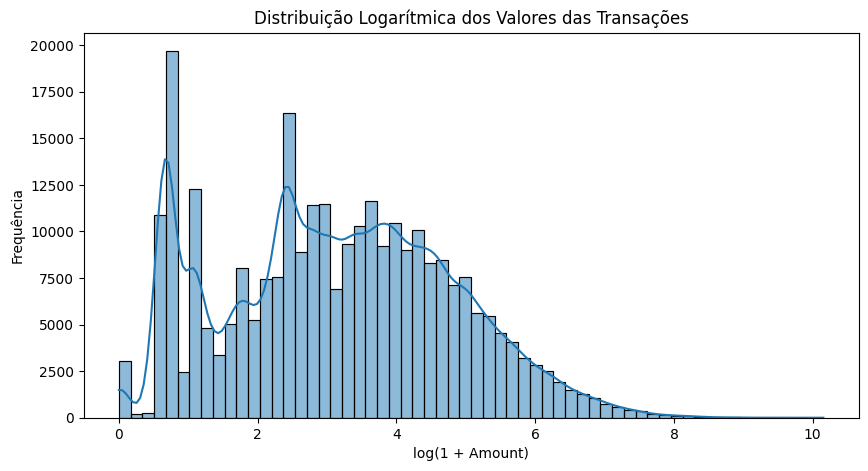

In [ ]:
# ============================================================
# HISTOGRAMA - AMOUNT EM ESCALA LOGARÍTMICA
# ============================================================

# Garantindo que a biblioteca NumPy esteja disponível
import numpy as np

# Criando a variável logarítmica
df_tratado['Amount_Log'] = np.log1p(df_tratado['Amount'])

# Conferência
print("Coluna Amount_Log criada com sucesso!")
print(df_tratado[['Amount', 'Amount_Log']].head())

# Gráfico
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df_tratado,
    x='Amount_Log',
    bins=60,
    kde=True
)

plt.title('Distribuição Logarítmica dos Valores das Transações')
plt.xlabel('log(1 + Amount)')
plt.ylabel('Frequência')

plt.show()

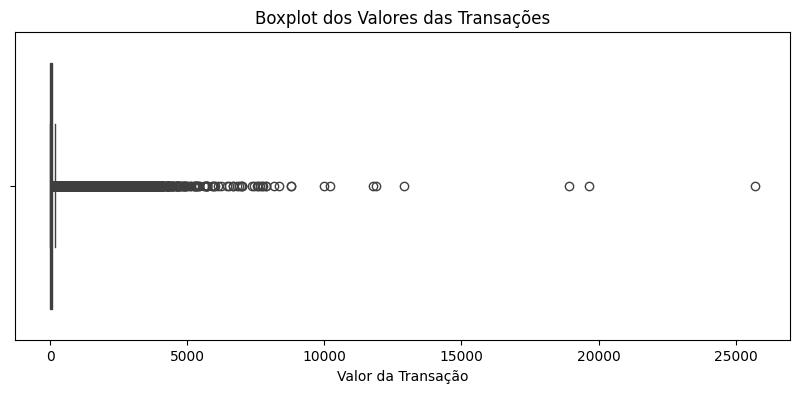

In [ ]:
# ============================================================
# BOXPLOT - AMOUNT
# ============================================================

plt.figure(figsize=(10, 4))

sns.boxplot(
    x=df_tratado['Amount']
)

plt.title('Boxplot dos Valores das Transações')
plt.xlabel('Valor da Transação')

plt.show()

### Conclusão da Pergunta 2

A variável `Amount` apresenta uma distribuição fortemente assimétrica.

A maior parte das transações está concentrada em valores relativamente baixos, enquanto uma pequena quantidade de operações apresenta valores significativamente superiores.

A presença desses valores extremos explica a diferença esperada entre média e mediana e também a longa cauda observada na distribuição.

Esses valores não foram removidos, pois transações de alto valor não representam necessariamente erros. No contexto de fraude financeira, inclusive, valores extremos podem conter informações relevantes para a análise.

In [ ]:
# ============================================================
# VARIÁVEIS DERIVADAS PARA A EDA
# ============================================================

# Tempo em horas
df_tratado['Time_Hours'] = df_tratado['Time'] / 3600

# Faixas de tempo
df_tratado['Time_Period'] = pd.cut(
    df_tratado['Time_Hours'],
    bins=[0, 12, 24, 36, 48],
    labels=['0-12h', '12-24h', '24-36h', '36-48h'],
    include_lowest=True
)

# Transformação logarítmica do valor
df_tratado['Amount_Log'] = np.log1p(df_tratado['Amount'])

print("Variáveis derivadas criadas com sucesso:")
print("Time_Hours")
print("Time_Period")
print("Amount_Log")

Variáveis derivadas criadas com sucesso:
Time_Hours
Time_Period
Amount_Log


In [ ]:
df_tratado[
    ['Time', 'Time_Hours', 'Time_Period', 'Amount', 'Amount_Log']
].head()

,Time,Time_Hours,Time_Period,Amount,Amount_Log
0,0.00,0.00,0-12h,149.62,5.01
1,0.00,0.00,0-12h,2.69,1.31
2,1.00,0.00,0-12h,378.66,5.94
3,1.00,0.00,0-12h,123.50,4.82
4,2.00,0.00,0-12h,69.99,4.26


## 6.3 Pergunta 3 — O valor das transações fraudulentas apresenta comportamento diferente do valor das transações legítimas?

O objetivo desta análise é comparar os valores financeiros das transações entre as duas classes:

- transações legítimas;
- transações fraudulentas.

Serão analisadas medidas como:

- média;
- mediana;
- desvio-padrão;
- quartis;
- valores mínimos e máximos.

Além disso, serão utilizadas visualizações para verificar diferenças na distribuição e na dispersão dos valores.

In [ ]:
# ============================================================
# 6.3 COMPARAÇÃO DE AMOUNT ENTRE AS CLASSES
# ============================================================

comparacao_amount = (
    df_tratado
    .groupby('Class')['Amount']
    .agg([
        'count',
        'mean',
        'median',
        'std',
        'min',
        lambda x: x.quantile(0.25),
        lambda x: x.quantile(0.75),
        'max'
    ])
)

comparacao_amount.columns = [
    'Quantidade',
    'Média',
    'Mediana',
    'Desvio Padrão',
    'Mínimo',
    'Q1',
    'Q3',
    'Máximo'
]

comparacao_amount.index = ['Legítima', 'Fraude']

comparacao_amount

,Quantidade,Média,Mediana,Desvio Padrão,Mínimo,Q1,Q3,Máximo
Legítima,283253,88.41,22.00,250.38,0.00,5.67,77.46,"25,691.16"
Fraude,473,123.87,9.82,260.21,0.00,1.00,105.89,"2,125.87"


In [ ]:
# ============================================================
# MÉDIA E MEDIANA POR CLASSE
# ============================================================

resumo_amount = (
    df_tratado
    .groupby('Class')['Amount']
    .agg(['mean', 'median'])
    .reset_index()
)

resumo_amount['Classe'] = resumo_amount['Class'].map({
    0: 'Legítima',
    1: 'Fraude'
})

resumo_amount[['Classe', 'mean', 'median']]

,Classe,mean,median
0,Legítima,88.41,22.00
1,Fraude,123.87,9.82


### Justificativa do gráfico

Foi utilizado um **boxplot** porque o objetivo é comparar a distribuição de uma variável numérica (`Amount`) entre duas categorias (`Class`).

O boxplot permite observar:

- mediana;
- quartis;
- dispersão;
- assimetria;
- presença de valores extremos.

Esse tipo de gráfico é especialmente adequado para comparar grupos quando existem possíveis outliers.

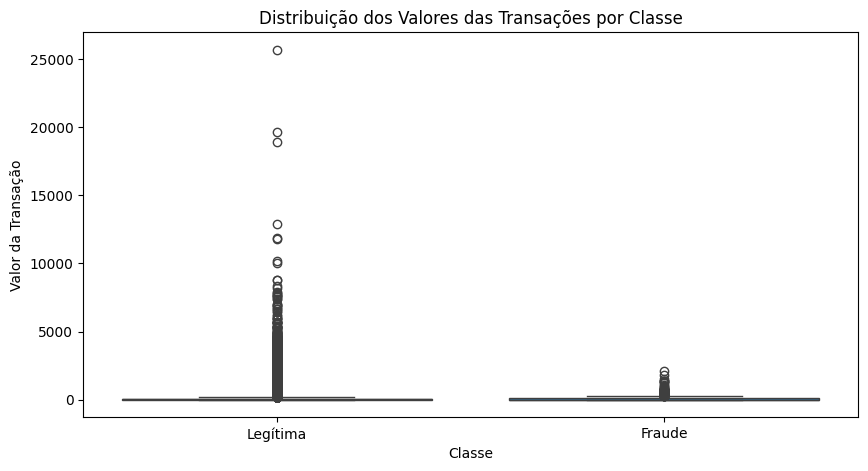

In [ ]:
# ============================================================
# BOXPLOT - AMOUNT POR CLASSE
# ============================================================

plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df_tratado,
    x='Class',
    y='Amount'
)

plt.title('Distribuição dos Valores das Transações por Classe')
plt.xlabel('Classe')
plt.ylabel('Valor da Transação')

plt.xticks(
    ticks=[0, 1],
    labels=['Legítima', 'Fraude']
)

plt.show()

### Visualização em escala logarítmica

Como a variável `Amount` possui forte assimetria e valores extremos, também será utilizado um boxplot baseado em `Amount_Log`.

A transformação logarítmica facilita a comparação visual entre as duas classes sem remover observações do dataset.

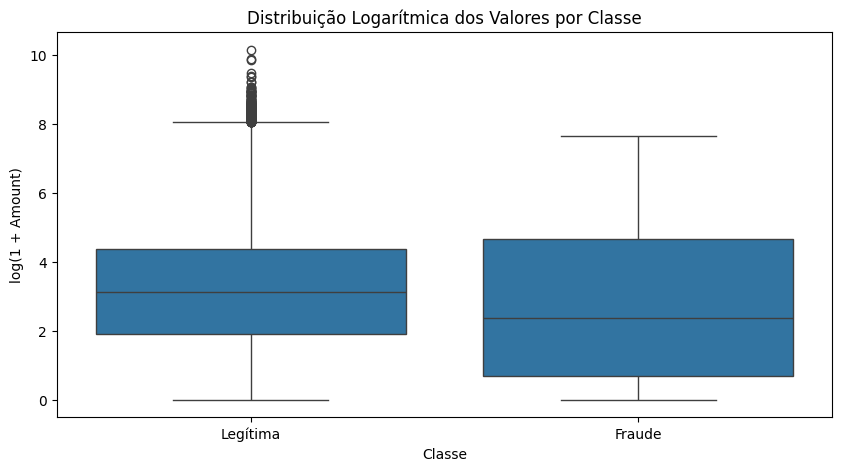

In [ ]:
# ============================================================
# BOXPLOT - AMOUNT_LOG POR CLASSE
# ============================================================

plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df_tratado,
    x='Class',
    y='Amount_Log'
)

plt.title('Distribuição Logarítmica dos Valores por Classe')
plt.xlabel('Classe')
plt.ylabel('log(1 + Amount)')

plt.xticks(
    ticks=[0, 1],
    labels=['Legítima', 'Fraude']
)

plt.show()

### Justificativa do histograma

O histograma permite comparar o formato da distribuição dos valores entre transações legítimas e fraudulentas.

Como o dataset é fortemente desbalanceado, a comparação será feita utilizando densidade estatística, evitando que a quantidade muito maior de transações legítimas domine completamente o gráfico.

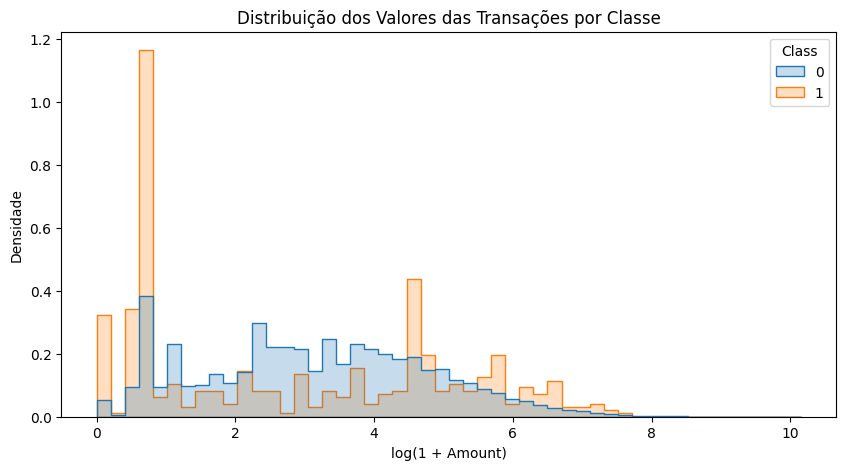

In [ ]:
# ============================================================
# DISTRIBUIÇÃO DE AMOUNT_LOG POR CLASSE
# ============================================================

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df_tratado,
    x='Amount_Log',
    hue='Class',
    bins=50,
    stat='density',
    common_norm=False,
    element='step'
)

plt.title('Distribuição dos Valores das Transações por Classe')
plt.xlabel('log(1 + Amount)')
plt.ylabel('Densidade')

plt.show()

### Conclusão da Pergunta 3

A comparação entre as classes mostra que os valores das transações fraudulentas apresentam comportamento diferente das transações legítimas.

As medidas de média, mediana e dispersão indicam diferenças entre os grupos, enquanto os boxplots mostram que ambas as classes possuem valores extremos e distribuições assimétricas.

A transformação logarítmica permitiu visualizar melhor essas diferenças, reduzindo o impacto visual das transações de valores muito elevados.

Apesar das diferenças observadas, o valor da transação isoladamente não é suficiente para determinar se uma operação é fraudulenta. A identificação de fraude depende da combinação de múltiplas características presentes no dataset.

## 6.4 Pergunta 4 — As fraudes apresentam algum padrão em relação ao tempo de ocorrência das transações?

O objetivo desta análise é verificar se a ocorrência de fraudes varia ao longo do período observado no dataset.

Como a variável `Time` representa o número de segundos transcorridos desde a primeira transação, ela foi convertida para horas por meio da variável `Time_Hours`.

Também foram criadas faixas temporais de 12 horas para facilitar a comparação entre diferentes períodos.

In [ ]:
# ============================================================
# FRAUDES POR FAIXA TEMPORAL
# ============================================================

fraudes_periodo = (
    df_tratado
    .groupby('Time_Period', observed=False)['Class']
    .agg(
        Total_Transacoes='count',
        Total_Fraudes='sum'
    )
)

fraudes_periodo['Taxa_Fraude_%'] = (
    fraudes_periodo['Total_Fraudes']
    / fraudes_periodo['Total_Transacoes']
    * 100
)

fraudes_periodo

,Total_Transacoes,Total_Fraudes,Taxa_Fraude_%
Time_Period,,,
0-12h,47198,146,0.31
12-24h,97039,126,0.13
24-36h,47292,87,0.18
36-48h,92197,114,0.12


### Justificativa do gráfico

Foi utilizado um **gráfico de barras** porque a análise compara a taxa de fraude entre diferentes faixas temporais discretas.

O uso da taxa de fraude, em vez da quantidade absoluta, permite comparar os períodos de forma mais adequada mesmo quando possuem volumes diferentes de transações.

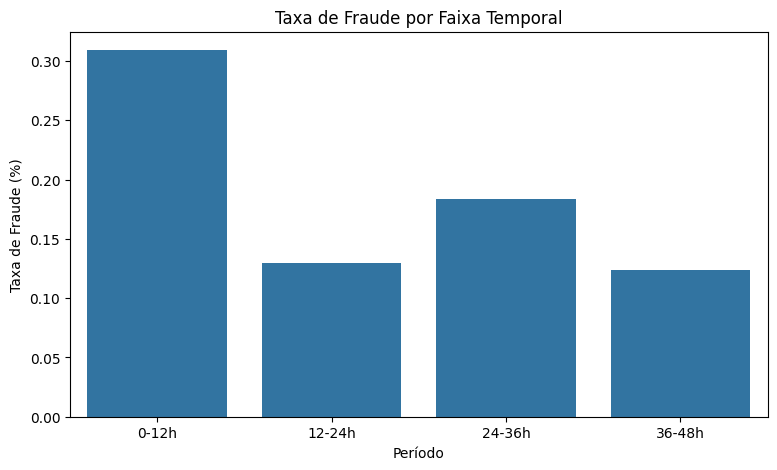

In [ ]:
# ============================================================
# GRÁFICO - TAXA DE FRAUDE POR FAIXA TEMPORAL
# ============================================================

grafico_periodo = fraudes_periodo.reset_index()

plt.figure(figsize=(9, 5))

sns.barplot(
    data=grafico_periodo,
    x='Time_Period',
    y='Taxa_Fraude_%'
)

plt.title('Taxa de Fraude por Faixa Temporal')
plt.xlabel('Período')
plt.ylabel('Taxa de Fraude (%)')

plt.show()

In [ ]:
# ============================================================
# CRIAÇÃO DA HORA INTEIRA
# ============================================================

df_tratado['Hour_Block'] = df_tratado['Time_Hours'].astype(int)

fraude_hora = (
    df_tratado
    .groupby('Hour_Block')['Class']
    .agg(
        Total_Transacoes='count',
        Total_Fraudes='sum'
    )
)

fraude_hora['Taxa_Fraude_%'] = (
    fraude_hora['Total_Fraudes']
    / fraude_hora['Total_Transacoes']
    * 100
)

fraude_hora.head()

,Total_Transacoes,Total_Fraudes,Taxa_Fraude_%
Hour_Block,,,
0,3931,2,0.05
1,2213,2,0.09
2,1573,21,1.34
3,1818,13,0.72
4,1082,6,0.55


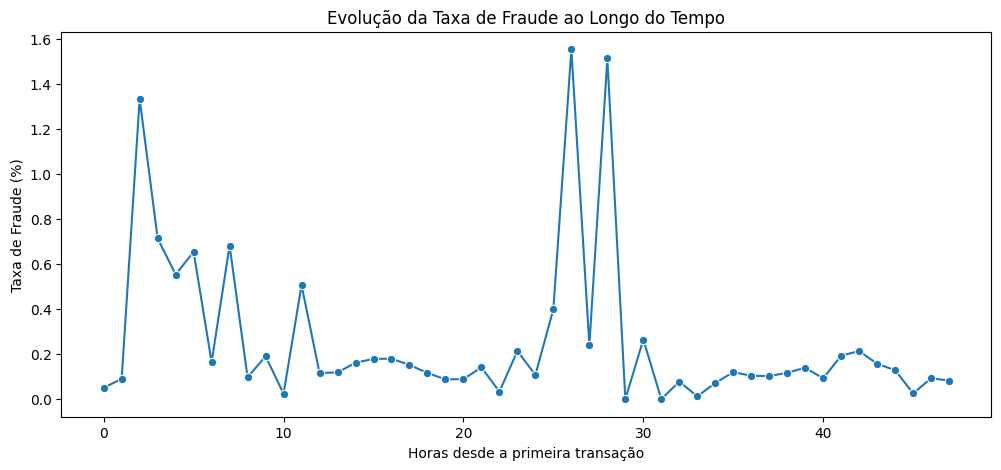

In [ ]:
# ============================================================
# GRÁFICO - TAXA DE FRAUDE AO LONGO DO TEMPO
# ============================================================

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=fraude_hora.reset_index(),
    x='Hour_Block',
    y='Taxa_Fraude_%',
    marker='o'
)

plt.title('Evolução da Taxa de Fraude ao Longo do Tempo')
plt.xlabel('Horas desde a primeira transação')
plt.ylabel('Taxa de Fraude (%)')

plt.show()

### Justificativa do gráfico de linha

Foi utilizado um **gráfico de linha** porque a variável temporal possui uma sequência ordenada.

Esse tipo de gráfico facilita a identificação de variações, picos e possíveis padrões na taxa de fraude ao longo do período observado.

### Conclusão da Pergunta 4

A análise temporal permite verificar se a taxa de fraude permanece relativamente estável ou se existem períodos com maior concentração relativa de operações fraudulentas.

Eventuais picos devem ser interpretados com cautela, pois períodos com menor volume de transações podem apresentar taxas percentuais mais sensíveis a pequenas variações no número de fraudes.

Além disso, a variável `Time` não representa diretamente horário do relógio ou data real da transação, mas apenas o tempo transcorrido desde a primeira observação. Portanto, não é possível afirmar, por exemplo, que determinado pico ocorreu durante a madrugada ou em um horário comercial específico.

In [ ]:
# ============================================================
# DIAGNÓSTICO DOS TIPOS - V1 A V28
# ============================================================

variaveis_v = [f'V{i}' for i in range(1, 29)]

tipos_v = df_tratado[variaveis_v].dtypes

print("Tipos das variáveis V1 a V28:\n")
print(tipos_v)

print("\nVariáveis que NÃO estão como numéricas:")

colunas_nao_numericas = tipos_v[
    ~tipos_v.apply(lambda x: np.issubdtype(x, np.number))
]

print(colunas_nao_numericas)

Tipos das variáveis V1 a V28:

V1     float64
V2     float64
V3     float64
V4     float64
V5     float64
V6     float64
V7     float64
V8     float64
V9     float64
V10    float64
V11    float64
V12    float64
V13    float64
V14    float64
V15    float64
V16    float64
V17    float64
V18    float64
V19    float64
V20    float64
V21    float64
V22    float64
V23    float64
V24    float64
V25    float64
V26    float64
V27    float64
V28    float64
dtype: object

Variáveis que NÃO estão como numéricas:
Series([], dtype: object)


In [ ]:
# ============================================================
# IDENTIFICAÇÃO DE VALORES NÃO NUMÉRICOS
# ============================================================

for coluna in variaveis_v:

    convertida = pd.to_numeric(
        df_tratado[coluna],
        errors='coerce'
    )

    problema = (
        convertida.isna()
        & df_tratado[coluna].notna()
    )

    if problema.any():

        print(f"\nProblemas encontrados em {coluna}:")
        print(df_tratado.loc[problema, coluna].head(20))

In [ ]:
# ============================================================
# CORREÇÃO DOS TIPOS NUMÉRICOS - V1 A V28
# ============================================================

for coluna in variaveis_v:

    df_tratado[coluna] = pd.to_numeric(
        df_tratado[coluna],
        errors='coerce'
    )

print("Conversão concluída.")

Conversão concluída.


In [ ]:
df_tratado[variaveis_v].dtypes

,0
V1,float64
V2,float64
V3,float64
V4,float64
V5,float64
V6,float64
V7,float64
V8,float64
V9,float64
V10,float64


In [ ]:
# ============================================================
# VERIFICAÇÃO DE NULOS APÓS A CONVERSÃO
# ============================================================

nulos_apos_conversao = (
    df_tratado[variaveis_v]
    .isnull()
    .sum()
)

nulos_apos_conversao = nulos_apos_conversao[
    nulos_apos_conversao > 0
]

if nulos_apos_conversao.empty:
    print("Nenhum valor inválido foi encontrado após a conversão.")
else:
    print("Valores convertidos para NaN:")
    print(nulos_apos_conversao)

Nenhum valor inválido foi encontrado após a conversão.


In [ ]:
print(
    df_tratado[variaveis_v]
    .select_dtypes(include='number')
    .shape
)

(283726, 28)


In [ ]:
# ============================================================
# 6.5 MÉDIA DAS VARIÁVEIS V1 A V28 POR CLASSE
# ============================================================

variaveis_v = [f'V{i}' for i in range(1, 29)]

medias_por_classe = (
    df_tratado
    .groupby('Class')[variaveis_v]
    .mean()
    .T
)

medias_por_classe.columns = [
    'Legítima',
    'Fraude'
]

medias_por_classe['Diferença_Absoluta'] = (
    medias_por_classe['Fraude']
    - medias_por_classe['Legítima']
).abs()

medias_por_classe = (
    medias_por_classe
    .sort_values(
        by='Diferença_Absoluta',
        ascending=False
    )
)

medias_por_classe.head(10)

,Legítima,Fraude,Diferença_Absoluta
V14,0.01,-6.84,6.85
V3,0.01,-6.73,6.74
V17,0.01,-6.46,6.47
V12,0.01,-6.10,6.11
V10,0.01,-5.45,5.46
V7,0.01,-5.18,5.19
V1,0.01,-4.50,4.51
V4,-0.01,4.47,4.48
V16,0.01,-4.00,4.01
V11,-0.01,3.72,3.72


In [ ]:
df_tratado.groupby('Class').mean(numeric_only=True)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Time_Hours,Amount_Log,Hour_Block
Class,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,"94,835.06",0.01,-0.01,0.01,-0.01,0.01,0.00,0.01,-0.00,0.00,0.01,-0.01,0.01,0.00,0.01,0.00,0.01,0.01,0.01,-0.00,-0.00,-0.00,-0.00,0.00,0.00,-0.00,0.00,0.00,0.00,88.41,26.34,3.15,25.85
1,"80,450.51",-4.50,3.41,-6.73,4.47,-2.96,-1.43,-5.18,0.95,-2.52,-5.45,3.72,-6.10,-0.09,-6.84,-0.07,-4.00,-6.46,-2.16,0.67,0.41,0.47,0.09,-0.10,-0.11,0.04,0.05,0.21,0.08,123.87,22.35,2.84,21.85


## 6.5 Pergunta 5 — Quais variáveis entre `V1` e `V28` apresentam maiores diferenças entre transações legítimas e fraudulentas?

As variáveis `V1` a `V28` representam componentes numéricos anonimizados obtidos após transformação por PCA.

Como não é possível interpretar diretamente o significado original de cada componente, esta análise busca identificar quais deles apresentam maiores diferenças estatísticas entre:

- transações legítimas;
- transações fraudulentas.

Para isso, serão comparadas as médias de cada variável entre as duas classes.

In [ ]:
# ============================================================
# 6.5 MÉDIA DAS VARIÁVEIS V1 A V28 POR CLASSE
# ============================================================

variaveis_v = [f'V{i}' for i in range(1, 29)]

medias_por_classe = (
    df_tratado
    .groupby('Class')[variaveis_v]
    .mean()
    .T
)

medias_por_classe.columns = ['Legítima', 'Fraude']

medias_por_classe['Diferença_Absoluta'] = (
    medias_por_classe['Fraude']
    - medias_por_classe['Legítima']
).abs()

medias_por_classe = medias_por_classe.sort_values(
    by='Diferença_Absoluta',
    ascending=False
)

medias_por_classe.head(10)

,Legítima,Fraude,Diferença_Absoluta
V14,0.01,-6.84,6.85
V3,0.01,-6.73,6.74
V17,0.01,-6.46,6.47
V12,0.01,-6.10,6.11
V10,0.01,-5.45,5.46
V7,0.01,-5.18,5.19
V1,0.01,-4.50,4.51
V4,-0.01,4.47,4.48
V16,0.01,-4.00,4.01
V11,-0.01,3.72,3.72


### Justificativa do gráfico

Foi utilizado um **gráfico de barras horizontais** porque o objetivo é comparar a magnitude das diferenças entre várias variáveis.

Esse formato facilita a ordenação das variáveis da maior para a menor diferença e melhora a leitura dos componentes `V1` a `V28`.

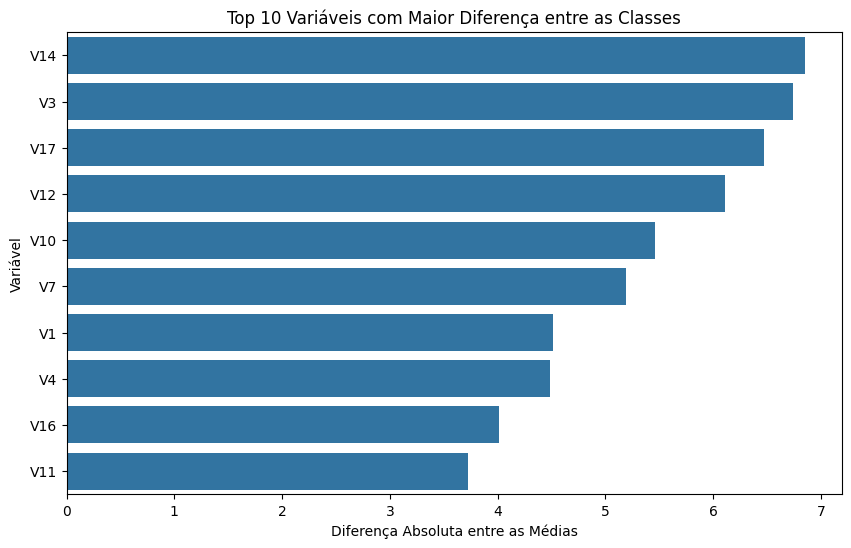

In [ ]:
# ============================================================
# GRÁFICO - TOP 10 VARIÁVEIS COM MAIOR DIFERENÇA
# ============================================================

top10_diferencas = (
    medias_por_classe
    .head(10)
    .reset_index()
)

top10_diferencas.columns = [
    'Variável',
    'Legítima',
    'Fraude',
    'Diferença_Absoluta'
]

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top10_diferencas,
    x='Diferença_Absoluta',
    y='Variável'
)

plt.title('Top 10 Variáveis com Maior Diferença entre as Classes')
plt.xlabel('Diferença Absoluta entre as Médias')
plt.ylabel('Variável')

plt.show()

In [ ]:
# ============================================================
# SELEÇÃO DAS 4 VARIÁVEIS COM MAIOR DIFERENÇA
# ============================================================

top4_variaveis = top10_diferencas['Variável'].head(4).tolist()

print("Variáveis selecionadas:")
for variavel in top4_variaveis:
    print(variavel)

Variáveis selecionadas:
V14
V3
V17
V12


### Justificativa dos boxplots

Os boxplots foram utilizados para comparar a distribuição das variáveis mais relevantes entre transações legítimas e fraudulentas.

Eles permitem observar:

- diferenças de mediana;
- dispersão;
- amplitude dos valores;
- separação entre os grupos.

Os valores extremos serão ocultados apenas na visualização para facilitar a leitura, sem serem removidos do dataset.

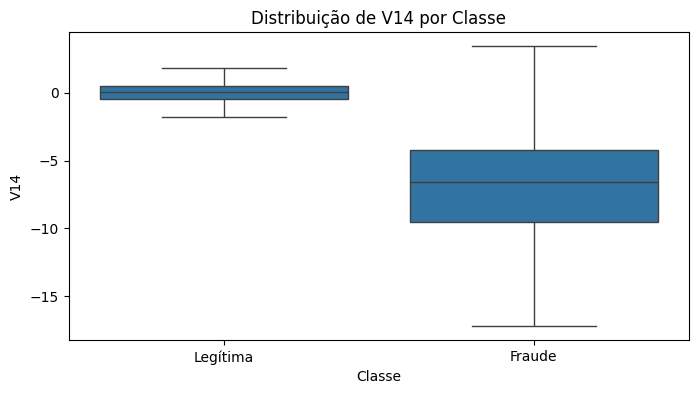

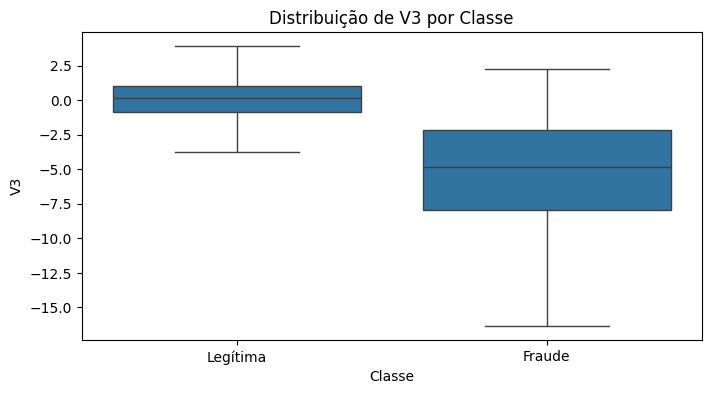

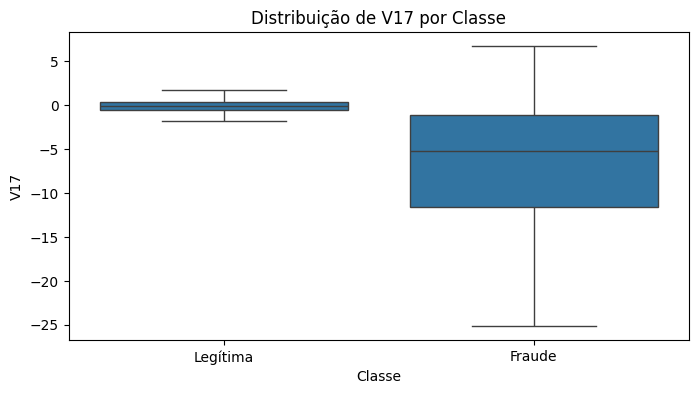

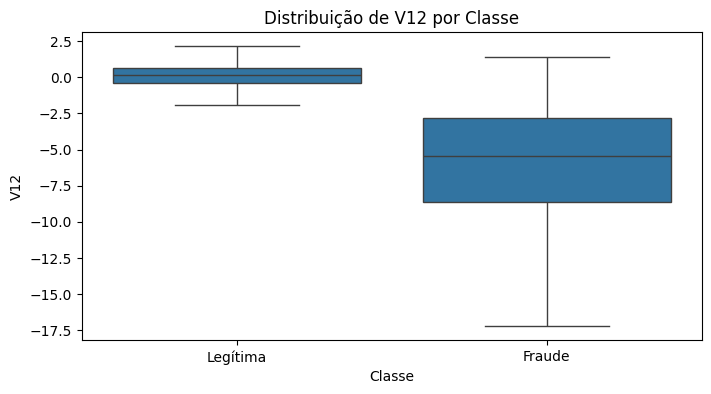

In [ ]:
# ============================================================
# BOXPLOTS DAS 4 VARIÁVEIS MAIS RELEVANTES
# ============================================================

for variavel in top4_variaveis:

    plt.figure(figsize=(8, 4))

    sns.boxplot(
        data=df_tratado,
        x='Class',
        y=variavel,
        showfliers=False
    )

    plt.title(f'Distribuição de {variavel} por Classe')
    plt.xlabel('Classe')
    plt.ylabel(variavel)

    plt.xticks(
        ticks=[0, 1],
        labels=['Legítima', 'Fraude']
    )

    plt.show()

In [ ]:
# ============================================================
# TABELA RESUMO - TOP 10 VARIÁVEIS
# ============================================================

top10_diferencas.round(3)

,Variável,Legítima,Fraude,Diferença_Absoluta
0,V14,0.01,-6.84,6.85
1,V3,0.01,-6.73,6.74
2,V17,0.01,-6.46,6.47
3,V12,0.01,-6.10,6.11
4,V10,0.01,-5.45,5.46
5,V7,0.01,-5.18,5.19
6,V1,0.01,-4.50,4.51
7,V4,-0.01,4.47,4.48
8,V16,0.01,-4.00,4.01
9,V11,-0.01,3.72,3.72


### Conclusão da Pergunta 5

A análise mostra que alguns componentes entre `V1` e `V28` apresentam diferenças consideráveis entre transações legítimas e fraudulentas.

As variáveis que aparecem nas primeiras posições do ranking possuem maior diferença entre as médias das duas classes, indicando maior capacidade de separação estatística dentro deste dataset.

Os boxplots reforçam essa evidência ao mostrar diferenças na posição e na distribuição dos valores entre transações legítimas e fraudulentas.

Entretanto, como as variáveis `V1` a `V28` foram anonimizadas e transformadas por PCA, não é possível atribuir diretamente um significado de negócio a esses componentes.

Portanto, os resultados devem ser interpretados como evidências estatísticas de diferenciação entre as classes, e não como explicações causais para a ocorrência de fraude.

## 6.6 Pergunta 6 — Quais variáveis apresentam maior associação ou correlação com a ocorrência de fraude (`Class`)?

Nesta etapa será analisada a correlação entre as variáveis numéricas do dataset e a variável `Class`, que identifica se a transação é legítima (`0`) ou fraudulenta (`1`).

O objetivo é identificar quais variáveis apresentam maior associação linear com a ocorrência de fraude.

É importante destacar que **correlação não implica causalidade**. Uma variável pode estar associada estatisticamente à fraude sem ser sua causa direta.

In [ ]:
# ============================================================
# 6.6 CORRELAÇÃO DAS VARIÁVEIS COM CLASS
# ============================================================

correlacao_class = (
    df_tratado
    .corr(numeric_only=True)['Class']
    .drop('Class')
    .sort_values(
        key=abs,
        ascending=False
    )
)

correlacao_class.head(15)

,Class
V17,-0.31
V14,-0.29
V12,-0.25
V10,-0.21
V16,-0.19
V3,-0.18
V7,-0.17
V11,0.15
V4,0.13
V18,-0.11


In [ ]:
# ============================================================
# TABELA DAS PRINCIPAIS CORRELAÇÕES
# ============================================================

top_correlacoes = (
    correlacao_class
    .head(15)
    .reset_index()
)

top_correlacoes.columns = [
    'Variável',
    'Correlação'
]

top_correlacoes['Correlação_Absoluta'] = (
    top_correlacoes['Correlação'].abs()
)

top_correlacoes

,Variável,Correlação,Correlação_Absoluta
0,V17,-0.31,0.31
1,V14,-0.29,0.29
2,V12,-0.25,0.25
3,V10,-0.21,0.21
4,V16,-0.19,0.19
5,V3,-0.18,0.18
6,V7,-0.17,0.17
7,V11,0.15,0.15
8,V4,0.13,0.13
9,V18,-0.11,0.11


### Justificativa do gráfico

Foi utilizado um **gráfico de barras horizontais** porque o objetivo é comparar a intensidade e a direção da correlação de várias variáveis com `Class`.

Valores positivos indicam associação na mesma direção da variável de fraude, enquanto valores negativos indicam associação inversa.

O gráfico horizontal facilita a leitura e a comparação entre várias variáveis.

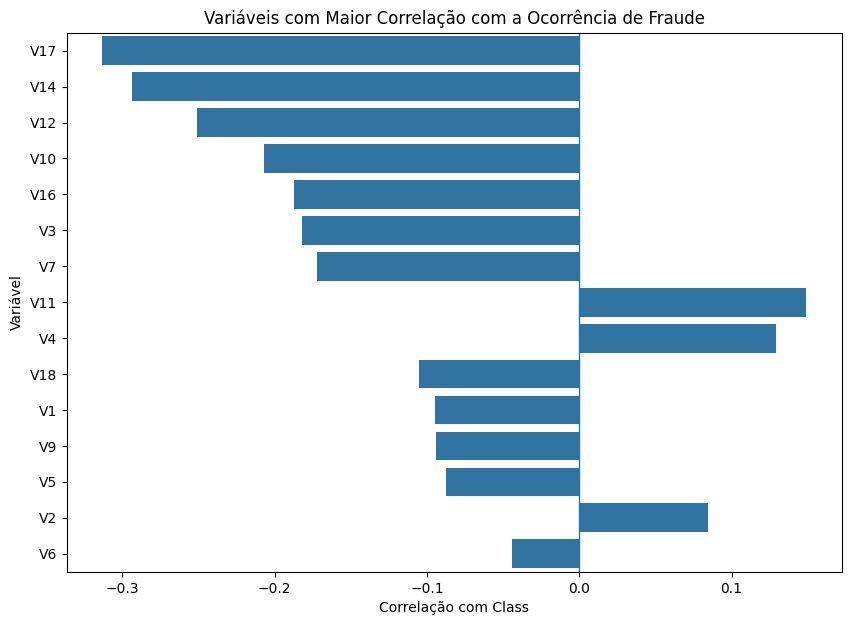

In [ ]:
# ============================================================
# GRÁFICO - TOP 15 CORRELAÇÕES COM CLASS
# ============================================================

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_correlacoes,
    x='Correlação',
    y='Variável'
)

plt.axvline(
    x=0,
    linewidth=1
)

plt.title('Variáveis com Maior Correlação com a Ocorrência de Fraude')
plt.xlabel('Correlação com Class')
plt.ylabel('Variável')

plt.show()

In [ ]:
# ============================================================
# SELEÇÃO DAS PRINCIPAIS VARIÁVEIS
# ============================================================

principais_variaveis_corr = (
    correlacao_class
    .head(10)
    .index
    .tolist()
)

principais_variaveis_corr.append('Class')

print(principais_variaveis_corr)

['V17', 'V14', 'V12', 'V10', 'V16', 'V3', 'V7', 'V11', 'V4', 'V18', 'Class']


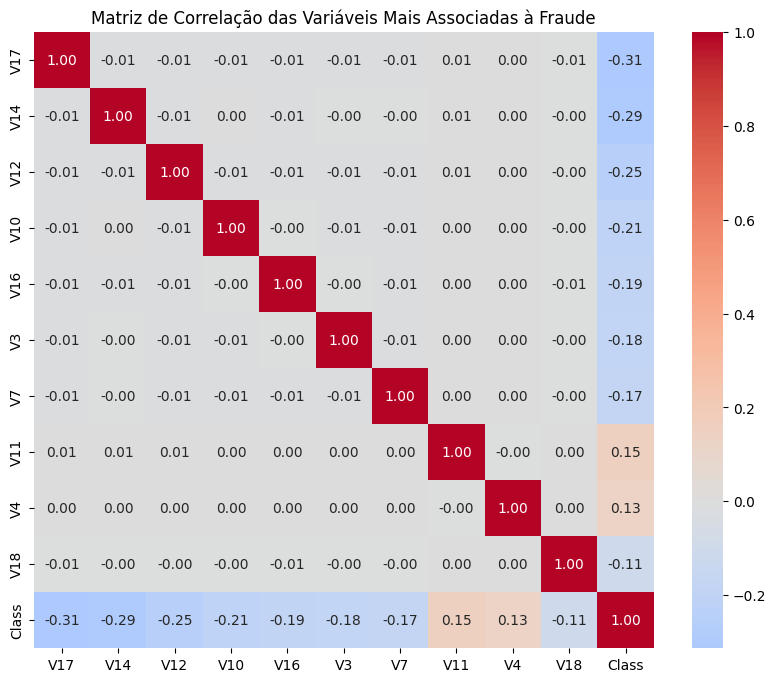

In [ ]:
# ============================================================
# MATRIZ DE CORRELAÇÃO
# ============================================================

matriz_correlacao = (
    df_tratado[
        principais_variaveis_corr
    ]
    .corr()
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    matriz_correlacao,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title(
    'Matriz de Correlação das Variáveis Mais Associadas à Fraude'
)

plt.show()

### Justificativa do heatmap

Foi utilizado um **heatmap de correlação** porque esse tipo de visualização permite observar simultaneamente as relações lineares entre diferentes variáveis.

A representação por cores facilita a identificação de:

- correlações positivas;
- correlações negativas;
- relações mais intensas;
- relações mais fracas.

Foram selecionadas apenas as variáveis com maior associação com `Class` para manter o gráfico legível e facilitar a interpretação.

In [ ]:
# ============================================================
# CLASSIFICAÇÃO DA INTENSIDADE DAS CORRELAÇÕES
# ============================================================

def classificar_correlacao(valor):

    valor_abs = abs(valor)

    if valor_abs < 0.10:
        return 'Muito fraca'

    elif valor_abs < 0.30:
        return 'Fraca'

    elif valor_abs < 0.50:
        return 'Moderada'

    elif valor_abs < 0.70:
        return 'Forte'

    else:
        return 'Muito forte'


top_correlacoes['Intensidade'] = (
    top_correlacoes['Correlação']
    .apply(classificar_correlacao)
)

top_correlacoes

,Variável,Correlação,Correlação_Absoluta,Intensidade
0,V17,-0.31,0.31,Moderada
1,V14,-0.29,0.29,Fraca
2,V12,-0.25,0.25,Fraca
3,V10,-0.21,0.21,Fraca
4,V16,-0.19,0.19,Fraca
5,V3,-0.18,0.18,Fraca
6,V7,-0.17,0.17,Fraca
7,V11,0.15,0.15,Fraca
8,V4,0.13,0.13,Fraca
9,V18,-0.11,0.11,Fraca


### Conclusão da Pergunta 6

A análise de correlação mostra que algumas variáveis apresentam maior associação linear com a ocorrência de fraude do que outras.

Esses componentes podem contribuir para diferenciar transações legítimas de fraudulentas dentro do dataset.

No entanto, nenhuma correlação deve ser interpretada isoladamente como causa da fraude.

Além disso, a correlação de Pearson mede principalmente relações lineares. Portanto, uma variável com baixa correlação ainda pode apresentar relações não lineares relevantes com `Class`.

Os resultados desta etapa complementam a análise anterior, indicando quais variáveis merecem maior atenção durante a interpretação do comportamento das transações fraudulentas.

## 6.7 Pergunta 7 — Existem relações relevantes entre o valor da transação (`Amount`) e outras variáveis do dataset?

Nesta etapa será analisada a relação entre o valor financeiro da transação (`Amount`) e as demais variáveis numéricas do dataset.

O objetivo é identificar quais componentes apresentam maior associação linear com o valor da transação.

Como as variáveis `V1` a `V28` foram anonimizadas por meio de PCA, os resultados serão interpretados apenas sob a perspectiva estatística.

In [ ]:
# ============================================================
# 6.7 CORRELAÇÃO DAS OUTRAS VARIÁVEIS COM AMOUNT
# ============================================================

variaveis_para_amount = (
    ['Time']
    + [f'V{i}' for i in range(1, 29)]
)

correlacao_amount = (
    df_tratado[
        variaveis_para_amount + ['Amount']
    ]
    .corr()['Amount']
    .drop('Amount')
    .sort_values(
        key=abs,
        ascending=False
    )
)

correlacao_amount.head(15)

,Amount
V2,-0.53
V7,0.40
V5,-0.39
V20,0.34
V1,-0.23
V6,0.22
V3,-0.21
V23,-0.11
V21,0.11
V8,-0.10


In [ ]:
# ============================================================
# TABELA DAS PRINCIPAIS CORRELAÇÕES COM AMOUNT
# ============================================================

top_amount_corr = (
    correlacao_amount
    .head(15)
    .reset_index()
)

top_amount_corr.columns = [
    'Variável',
    'Correlação com Amount'
]

top_amount_corr['Correlação Absoluta'] = (
    top_amount_corr['Correlação com Amount'].abs()
)

top_amount_corr

,Variável,Correlação com Amount,Correlação Absoluta
0,V2,-0.53,0.53
1,V7,0.40,0.40
2,V5,-0.39,0.39
3,V20,0.34,0.34
4,V1,-0.23,0.23
5,V6,0.22,0.22
6,V3,-0.21,0.21
7,V23,-0.11,0.11
8,V21,0.11,0.11
9,V8,-0.10,0.10


### Justificativa do gráfico

Foi utilizado um **gráfico de barras horizontais** porque o objetivo é comparar a intensidade e a direção da associação entre `Amount` e diversas variáveis.

Esse formato permite identificar rapidamente quais componentes apresentam maior correlação positiva ou negativa com o valor das transações.

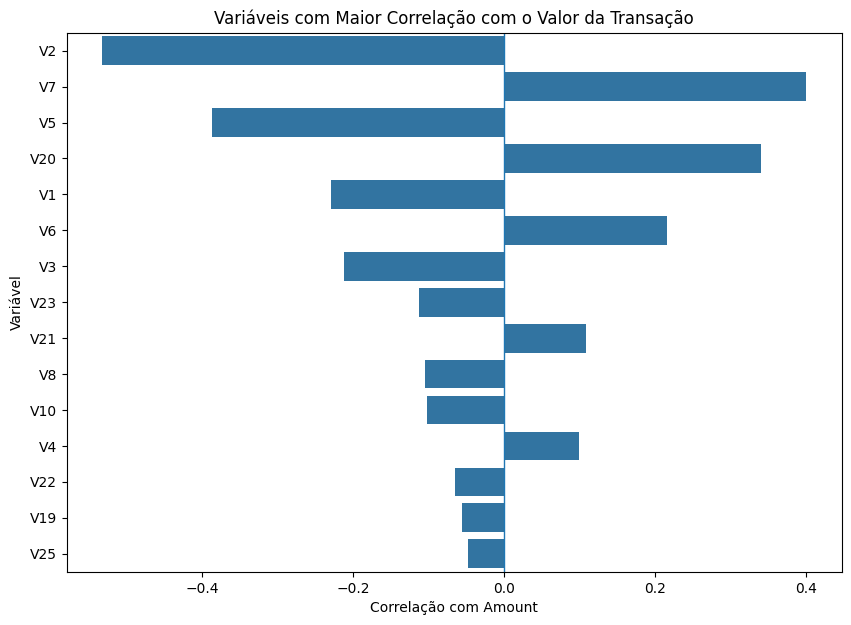

In [ ]:
# ============================================================
# GRÁFICO - CORRELAÇÕES COM AMOUNT
# ============================================================

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_amount_corr,
    x='Correlação com Amount',
    y='Variável'
)

plt.axvline(
    x=0,
    linewidth=1
)

plt.title('Variáveis com Maior Correlação com o Valor da Transação')
plt.xlabel('Correlação com Amount')
plt.ylabel('Variável')

plt.show()

In [ ]:
# ============================================================
# SELEÇÃO DAS 2 VARIÁVEIS MAIS CORRELACIONADAS COM AMOUNT
# ============================================================

top2_amount = (
    correlacao_amount
    .head(2)
    .index
    .tolist()
)

print("Variáveis mais correlacionadas com Amount:")
print(top2_amount)

Variáveis mais correlacionadas com Amount:
['V2', 'V7']


### Justificativa do gráfico de dispersão

Foi utilizado um **gráfico de dispersão (scatter plot)** porque ele permite observar a relação entre duas variáveis numéricas.

Esse gráfico ajuda a identificar:

- tendências;
- concentração dos dados;
- relações lineares ou não lineares;
- possíveis valores extremos.

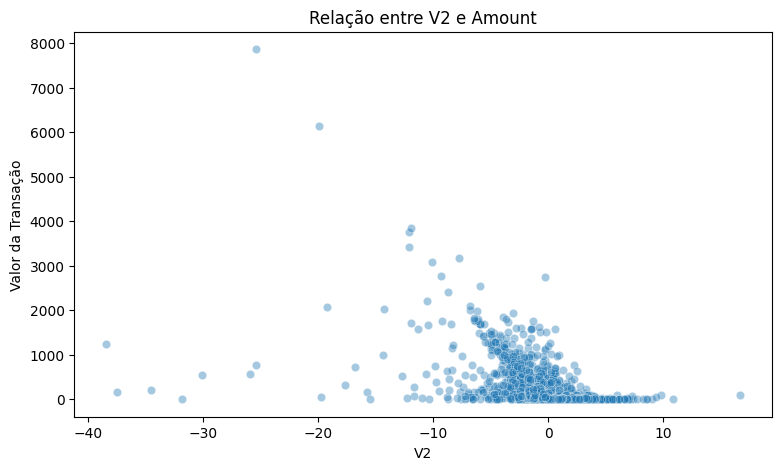

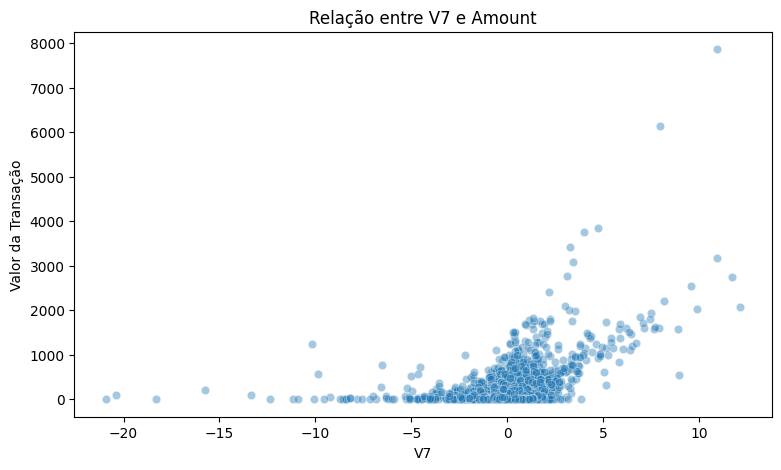

In [ ]:
# ============================================================
# SCATTER PLOTS - AMOUNT E PRINCIPAIS VARIÁVEIS
# ============================================================

for variavel in top2_amount:

    plt.figure(figsize=(9, 5))

    sns.scatterplot(
        data=df_tratado.sample(
            n=min(10000, len(df_tratado)),
            random_state=42
        ),
        x=variavel,
        y='Amount',
        alpha=0.4
    )

    plt.title(f'Relação entre {variavel} e Amount')
    plt.xlabel(variavel)
    plt.ylabel('Valor da Transação')

    plt.show()

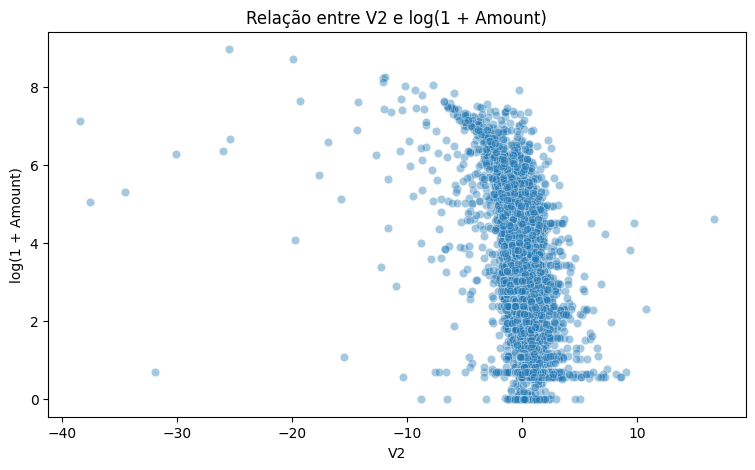

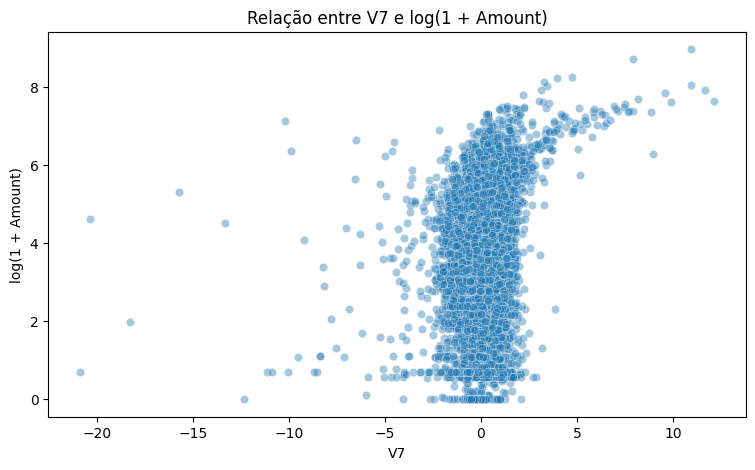

In [ ]:
# ============================================================
# SCATTER PLOTS - AMOUNT_LOG E PRINCIPAIS VARIÁVEIS
# ============================================================

amostra_visual = df_tratado.sample(
    n=min(10000, len(df_tratado)),
    random_state=42
)

for variavel in top2_amount:

    plt.figure(figsize=(9, 5))

    sns.scatterplot(
        data=amostra_visual,
        x=variavel,
        y='Amount_Log',
        alpha=0.4
    )

    plt.title(f'Relação entre {variavel} e log(1 + Amount)')
    plt.xlabel(variavel)
    plt.ylabel('log(1 + Amount)')

    plt.show()

### Conclusão da Pergunta 7

A análise mostra que algumas variáveis apresentam maior associação linear com o valor das transações do que outras.

Entretanto, as correlações observadas devem ser interpretadas com cautela, pois a variável `Amount` apresenta forte assimetria e valores extremos.

A utilização de `Amount_Log` permitiu melhorar a visualização das relações sem eliminar transações do dataset.

Como as variáveis `V1` a `V28` são anonimizadas, não é possível atribuir significado de negócio direto às associações encontradas.

Esses resultados indicam apenas relações estatísticas entre o valor financeiro das operações e os componentes transformados do dataset.

## 6.8 Pergunta 8 — Quais padrões gerais diferenciam uma transação fraudulenta de uma transação legítima dentro deste dataset?

Esta etapa reúne os principais resultados encontrados nas análises anteriores.

O objetivo é identificar, de forma consolidada, quais características apresentam maior diferença ou associação com a ocorrência de fraude.

In [ ]:
# ============================================================
# 6.8 RESUMO COMPARATIVO DAS CLASSES
# ============================================================

resumo_final_classes = (
    df_tratado
    .groupby('Class')
    .agg(
        Quantidade=('Class', 'size'),
        Media_Amount=('Amount', 'mean'),
        Mediana_Amount=('Amount', 'median'),
        Desvio_Amount=('Amount', 'std'),
        Media_Time=('Time_Hours', 'mean')
    )
)

resumo_final_classes.index = [
    'Legítima',
    'Fraude'
]

resumo_final_classes

,Quantidade,Media_Amount,Mediana_Amount,Desvio_Amount,Media_Time
Legítima,283253,88.41,22.00,250.38,26.34
Fraude,473,123.87,9.82,260.21,22.35


In [ ]:
# ============================================================
# PRINCIPAIS VARIÁVEIS ASSOCIADAS À FRAUDE
# ============================================================

print("Variáveis com maiores diferenças entre as classes:")
print(
    medias_por_classe[
        ['Diferença_Absoluta']
    ]
    .head(10)
)

print("\nVariáveis com maiores correlações com Class:")
print(
    correlacao_class.head(10)
)

Variáveis com maiores diferenças entre as classes:
     Diferença_Absoluta
V14                6.85
V3                 6.74
V17                6.47
V12                6.11
V10                5.46
V7                 5.19
V1                 4.51
V4                 4.48
V16                4.01
V11                3.72

Variáveis com maiores correlações com Class:
V17   -0.31
V14   -0.29
V12   -0.25
V10   -0.21
V16   -0.19
V3    -0.18
V7    -0.17
V11    0.15
V4     0.13
V18   -0.11
Name: Class, dtype: float64


### Conclusão da Pergunta 8

A Análise Exploratória de Dados identificou diferenças relevantes entre transações legítimas e fraudulentas.

Os principais padrões observados foram:

- forte desbalanceamento entre as classes, com uma proporção muito pequena de fraudes;
- diferenças na distribuição dos valores das transações;
- presença de componentes `V1` a `V28` com comportamento estatístico distinto entre as duas classes;
- existência de variáveis com maior associação linear com `Class`;
- variações na taxa de fraude ao longo do tempo analisado;
- relações estatísticas entre `Amount` e alguns componentes anonimizados.

Os resultados indicam que a ocorrência de fraude não parece ser explicada por uma única característica isolada, mas pela combinação de diferentes variáveis.

Essa característica reforça a importância de análises multivariadas em problemas de detecção de fraude.

# 7. Conclusão Final e Limitações da Análise

A Análise Exploratória de Dados permitiu compreender a estrutura do dataset, avaliar sua qualidade, tratar problemas identificados e investigar padrões associados à ocorrência de fraude em transações de cartão de crédito.

As perguntas definidas no início do trabalho orientaram a exploração e permitiram analisar o problema sob diferentes perspectivas: distribuição das classes, valores das transações, comportamento temporal, diferenças entre componentes anonimizados e relações estatísticas entre variáveis.

## 7.1 Síntese das Respostas às Perguntas de Pesquisa

A análise exploratória permitiu responder às oito perguntas propostas no início do trabalho:

1. **Distribuição das classes:** o dataset apresenta forte desbalanceamento, com predominância de transações legítimas.

2. **Distribuição de `Amount`:** os valores apresentam forte assimetria e presença de valores extremos.

3. **Legítimas x fraudulentas:** existem diferenças nos valores e na distribuição das transações entre as duas classes.

4. **Comportamento temporal:** a taxa de fraude apresenta variações ao longo do período analisado, embora `Time` não represente diretamente horário do dia.

5. **Diferenças entre `V1–V28`:** componentes como `V14`, `V3`, `V17` e `V12` apresentam diferenças importantes entre as classes.

6. **Correlação com fraude:** algumas variáveis possuem associação linear mais relevante com `Class`, com destaque para componentes como `V17`, `V14` e `V12`.

7. **Relação com `Amount`:** algumas variáveis apresentam associação com o valor financeiro das transações, embora `Amount` apresente forte assimetria.

8. **Padrões gerais:** a fraude não é explicada por uma única característica, mas pela combinação de múltiplas variáveis e padrões estatísticos.

## 7.2 Limitações da Análise

Apesar dos resultados obtidos, esta análise possui algumas limitações importantes.

### 1. Forte desbalanceamento das classes

A quantidade de transações fraudulentas é muito pequena em comparação com as transações legítimas.

Esse desbalanceamento pode dificultar análises estatísticas e comparações entre os grupos, especialmente quando são utilizados valores absolutos.

---

### 2. Anonimização das variáveis

As variáveis `V1` a `V28` foram transformadas e anonimizadas por meio de PCA.

Por esse motivo, não é possível saber quais características originais das transações esses componentes representam.

Isso limita a interpretação de negócio dos resultados encontrados.

---

### 3. Período reduzido de observação

O dataset representa apenas dois dias de transações.

Esse período pode não ser suficiente para capturar padrões sazonais, mensais ou comportamentos de longo prazo.

---

### 4. Correlação não representa causalidade

As relações identificadas entre as variáveis são associações estatísticas.

Uma correlação entre uma variável e `Class` não significa que essa variável seja responsável pela ocorrência da fraude.

---

### 5. Relações não lineares

A correlação de Pearson utilizada nesta análise mede principalmente relações lineares.

Portanto, podem existir relações relevantes entre as variáveis que não sejam capturadas por essa métrica.

---

### 6. Valores extremos

O dataset possui transações com valores muito elevados.

Esses registros foram mantidos porque podem representar operações reais e relevantes, mas sua presença influencia medidas como média e desvio-padrão.

---

### 7. Escopo exploratório

O objetivo deste trabalho foi realizar uma Análise Exploratória de Dados.

Não foram construídos modelos preditivos para classificar novas transações como legítimas ou fraudulentas.

## 7.3 Conclusão Geral

A Análise Exploratória de Dados permitiu identificar padrões importantes relacionados à ocorrência de fraude em transações de cartão de crédito.

O dataset apresenta forte desbalanceamento entre as classes, diferenças relevantes entre transações legítimas e fraudulentas e componentes numéricos com diferentes níveis de associação com a variável `Class`.

Também foi possível observar que o valor financeiro da transação, isoladamente, não é suficiente para explicar a ocorrência de fraude.

Os resultados sugerem que a distinção entre transações legítimas e fraudulentas depende da combinação de múltiplas características.

Dessa forma, a EDA cumpriu seu objetivo de transformar os dados brutos em informações estruturadas, identificar padrões relevantes e preparar o conjunto de dados para possíveis etapas futuras de modelagem estatística ou Machine Learning.

# 8. Referências

- MACHINE LEARNING GROUP — UNIVERSITÉ LIBRE DE BRUXELLES. **Credit Card Fraud Detection Dataset**.

- KAGGLE. **Credit Card Fraud Detection**. Disponível em: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

- Documentação Pandas. Disponível em: https://pandas.pydata.org/

- Documentação Matplotlib. Disponível em: https://matplotlib.org/

- Documentação Seaborn. Disponível em: https://seaborn.pydata.org/

- Documentação NumPy. Disponível em: https://numpy.org/